# Matplotlib 응용 - 고급 시각화 (한국어 폰트 설정)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 1. 다양한 차트 종류

## 바이올린 플롯 (Violin Plot)

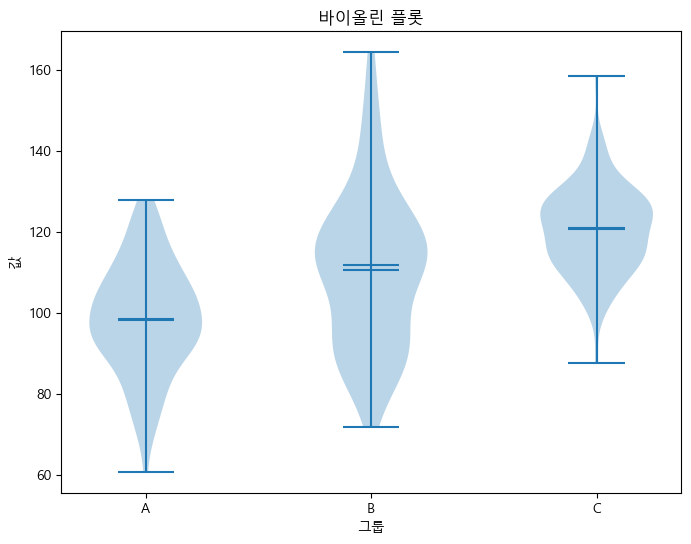

In [18]:
# 데이터 생성
data = [np.random.normal(100, 15, 100),
        np.random.normal(110, 20, 100),
        np.random.normal(120, 10, 100)]

fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(data, positions=[1, 2, 3], showmeans=True, showmedians=True)
ax.set_ylabel('값')
ax.set_xlabel('그룹')
ax.set_title('바이올린 플롯')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['A', 'B', 'C'])
plt.show()

## 버블 플롯 (Bubble Plot)

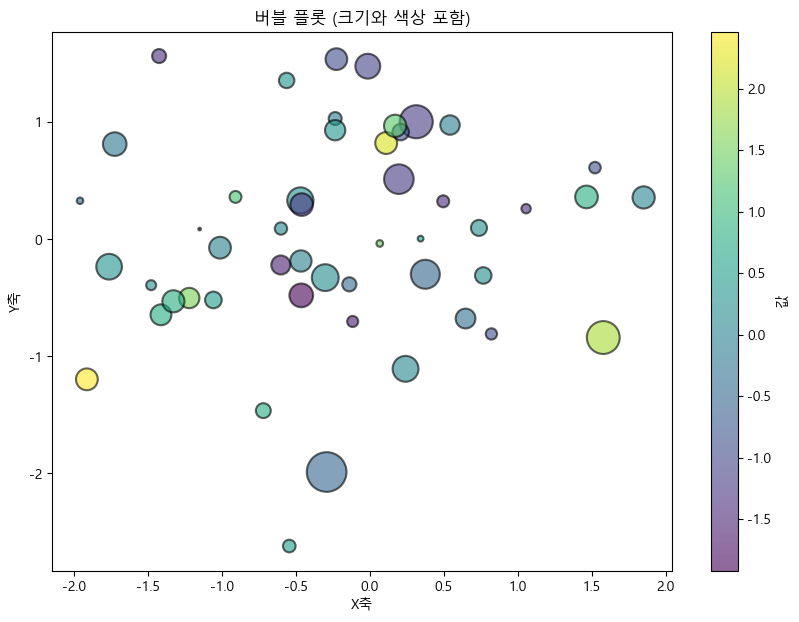

In [19]:
# 버블 플롯 - 변수 4개 표현
np.random.seed(42)
n = 50
x = np.random.randn(n)
y = np.random.randn(n)
colors = np.random.randn(n)
sizes = np.abs(np.random.randn(n)) * 300

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='viridis', edgecolors='black', linewidth=1.5)
ax.set_xlabel('X축')
ax.set_ylabel('Y축')
ax.set_title('버블 플롯 (크기와 색상 포함)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('값')
plt.show()

## 스캐터 + 히스토그램 결합

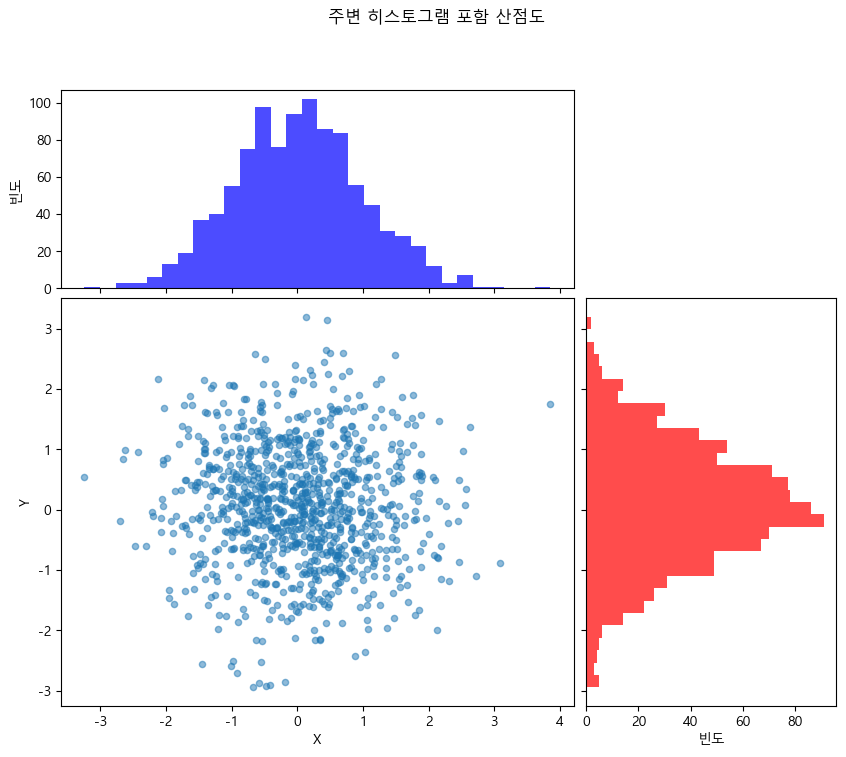

In [20]:
# 데이터
np.random.seed(42)
x = np.random.randn(1000)
y = np.random.randn(1000)

# 주변 히스토그램 포함 산점도
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05)

# 메인 산점도
ax_main = fig.add_subplot(gs[1:, :-1])
ax_main.scatter(x, y, alpha=0.5, s=20)
ax_main.set_xlabel('X')
ax_main.set_ylabel('Y')

# 상단 히스토그램
ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)
ax_top.hist(x, bins=30, alpha=0.7, color='blue')
ax_top.set_ylabel('빈도')
ax_top.tick_params(labelbottom=False)

# 오른쪽 히스토그램
ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)
ax_right.hist(y, bins=30, orientation='horizontal', alpha=0.7, color='red')
ax_right.set_xlabel('빈도')
ax_right.tick_params(labelleft=False)

plt.suptitle('주변 히스토그램 포함 산점도')
plt.show()

# 2. 복합 시각화 (Multiple Axes)

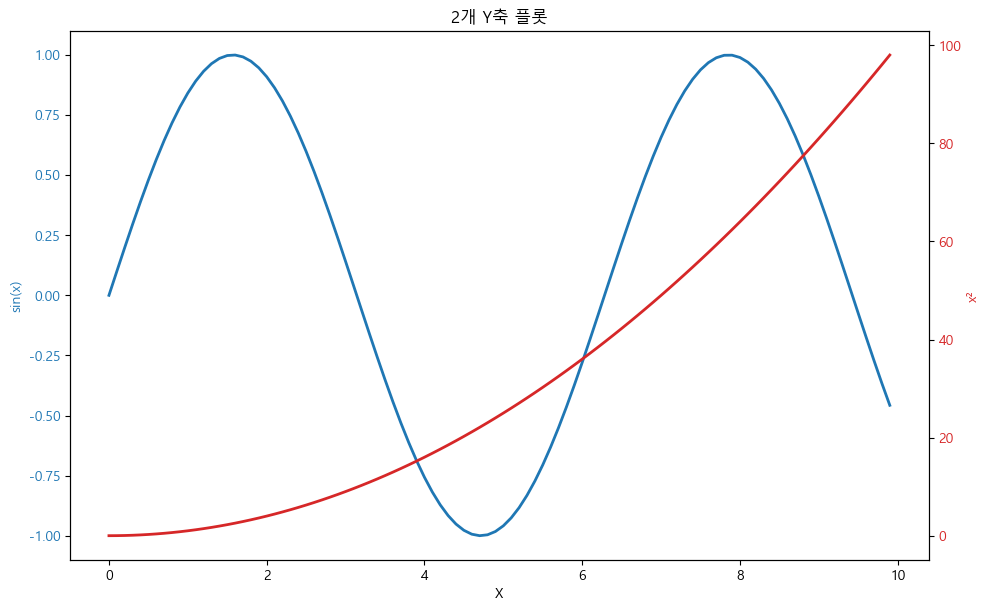

In [21]:
# 2개 Y축 플롯
x = np.arange(0, 10, 0.1)
y1 = np.sin(x)
y2 = x ** 2

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('X')
ax1.set_ylabel('sin(x)', color=color)
ax1.plot(x, y1, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# 두 번째 Y축
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('x²', color=color)
ax2.plot(x, y2, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('2개 Y축 플롯')
plt.show()

# 3. 애니메이션 효과

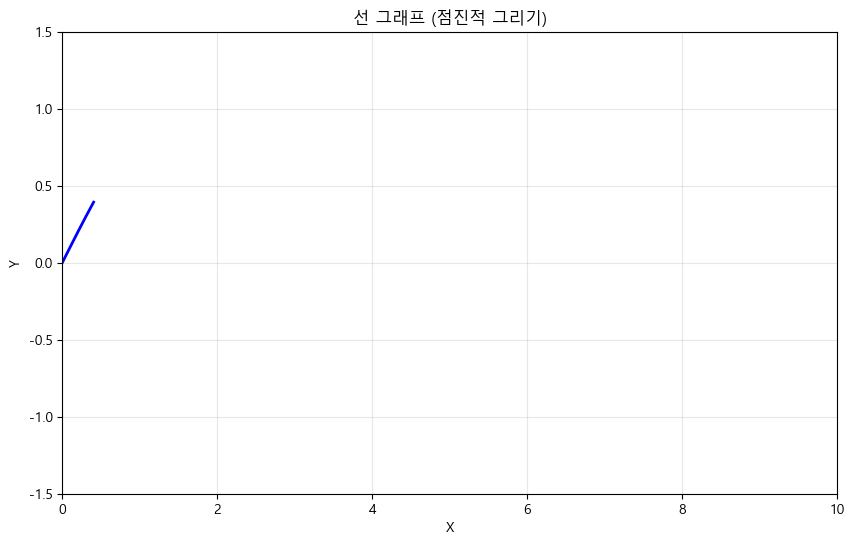

In [22]:
# 선 그래프 점진적 그리기 (시뮬레이션)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
y = np.sin(x)

# 점진적으로 데이터 표시
line, = ax.plot([], [], lw=2, color='blue')
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('선 그래프 (점진적 그리기)')
ax.grid(alpha=0.3)

# 데이터 점진적 추가
for i in range(0, len(x), 5):
    line.set_data(x[:i+5], y[:i+5])
    plt.pause(0.01)

plt.show()

# 4. 3D 시각화

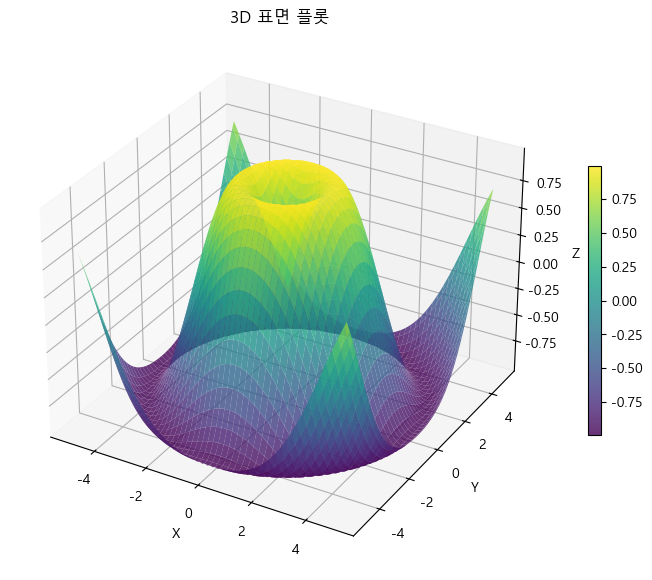

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# 3D 표면 플롯
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D 표면 플롯')
fig.colorbar(surf, shrink=0.5)
plt.show()

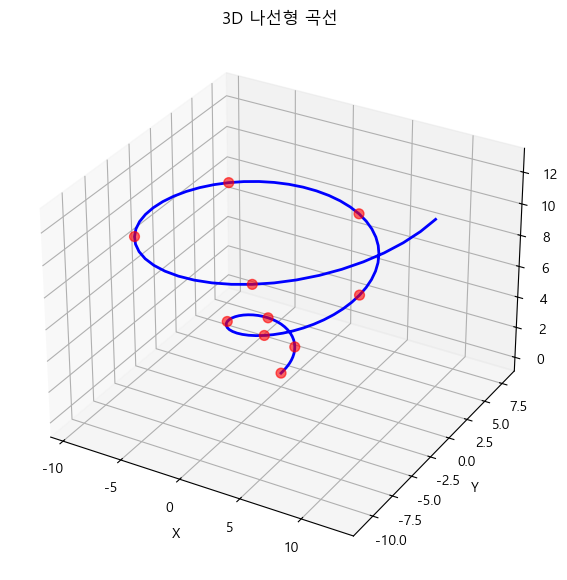

In [24]:
# 3D 선 그래프
theta = np.linspace(0, 4*np.pi, 100)
x = theta * np.cos(theta)
y = theta * np.sin(theta)
z = theta

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, lw=2, color='blue')
ax.scatter(x[::10], y[::10], z[::10], s=50, c='red', alpha=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D 나선형 곡선')
plt.show()

# 5. 이미지와 Heatmap 고급 활용

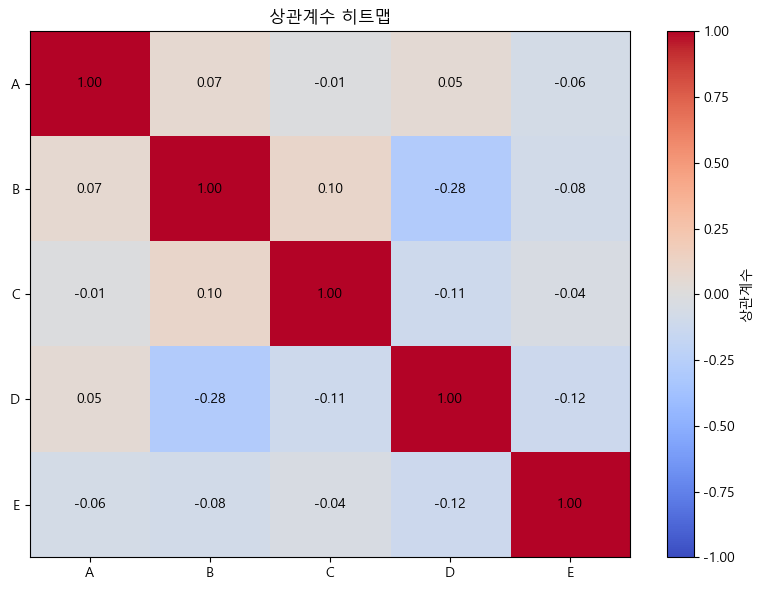

In [25]:
# 상관계수 히트맵
data = np.random.randn(100, 5)
df = pd.DataFrame(data, columns=['A', 'B', 'C', 'D', 'E'])
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# 라벨 설정
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

# 값 표시
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=10)

ax.set_title('상관계수 히트맵')
fig.colorbar(im, ax=ax, label='상관계수')
plt.tight_layout()
plt.show()

# 6. 스타일 커스터마이징

사용 가능한 스타일:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']


C:\Users\User\AppData\Local\Temp\ipykernel_20092\133334789.py:24: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\133334789.py:24: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\133334789.py:24: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\133334789.py:24: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45924 (\N{HA

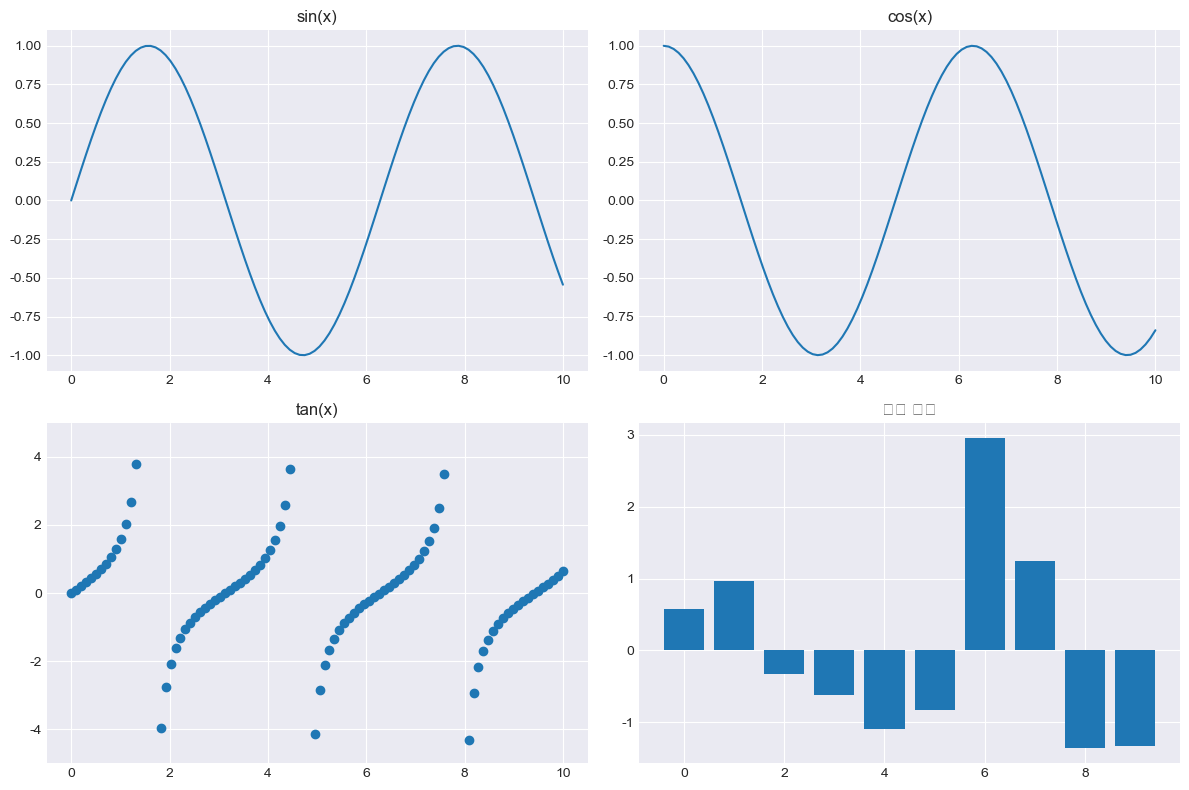

In [26]:
# 사용 가능한 스타일 확인
print('사용 가능한 스타일:')
print(plt.style.available[:10])  # 처음 10개만 출력

# 스타일 적용
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(0, 10, 100)
axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title('sin(x)')

axes[0, 1].plot(x, np.cos(x))
axes[0, 1].set_title('cos(x)')

axes[1, 0].scatter(x, np.tan(x))
axes[1, 0].set_title('tan(x)')
axes[1, 0].set_ylim(-5, 5)

axes[1, 1].bar(range(10), np.random.randn(10))
axes[1, 1].set_title('랜덤 막대')

plt.tight_layout()
plt.show()

# 스타일 초기화
plt.style.use('default')

# 7. 고급 텍스트 및 주석

Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc778' [U+c778], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud568' [U+d568], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc218' [U+c218], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub77c' [U+b77c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub514' [U+b514], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc548' [U+c548], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc778' [U+c778], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud568' [U+d568], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc218' [U+c218], 

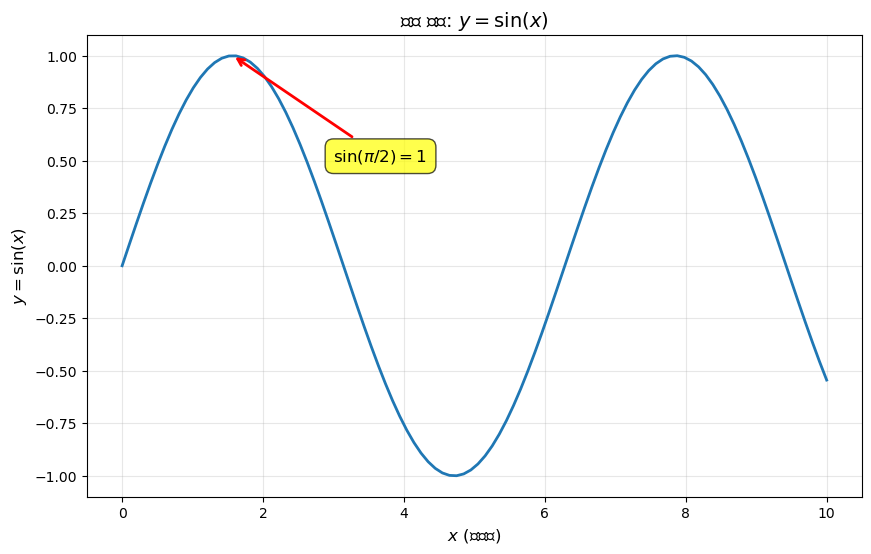

In [27]:
# 수학 표기법
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
y = np.sin(x)

ax.plot(x, y, linewidth=2)
ax.set_xlabel(r'$x$ (라디안)', fontsize=12)
ax.set_ylabel(r'$y = \sin(x)$', fontsize=12)
ax.set_title(r'사인 함수: $y = \sin(x)$', fontsize=14)

# 주석 추가
ax.annotate(r'$\sin(\pi/2) = 1$',
            xy=(np.pi/2, 1), xytext=(3, 0.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.grid(True, alpha=0.3)
plt.show()

# 8. 데이터 기반 시각화

C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\1699069499.py:42: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from current font.
  plt.tight_layout()


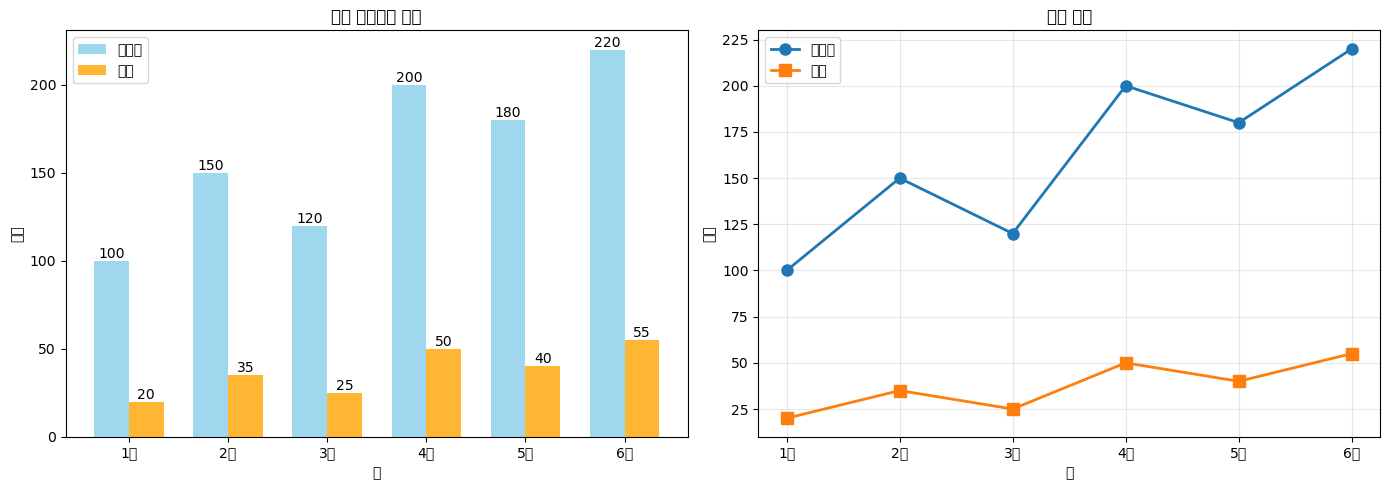

In [28]:
# 판매 데이터 시각화
months = ['1월', '2월', '3월', '4월', '5월', '6월']
sales = [100, 150, 120, 200, 180, 220]
profit = [20, 35, 25, 50, 40, 55]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
x = np.arange(len(months))
width = 0.35

bars1 = ax1.bar(x - width/2, sales, width, label='판매액', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, profit, width, label='이익', alpha=0.8, color='orange')

ax1.set_xlabel('월')
ax1.set_ylabel('금액')
ax1.set_title('월별 판매액과 이익')
ax1.set_xticks(x)
ax1.set_xticklabels(months)
ax1.legend()

# 값 표시
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 라인 플롯
ax2.plot(months, sales, marker='o', linewidth=2, markersize=8, label='판매액')
ax2.plot(months, profit, marker='s', linewidth=2, markersize=8, label='이익')
ax2.set_xlabel('월')
ax2.set_ylabel('금액')
ax2.set_title('월별 추세')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. 레이더 차트 (Radar Chart)

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46356 (\N{HANGUL SYLLABLE DI}) 

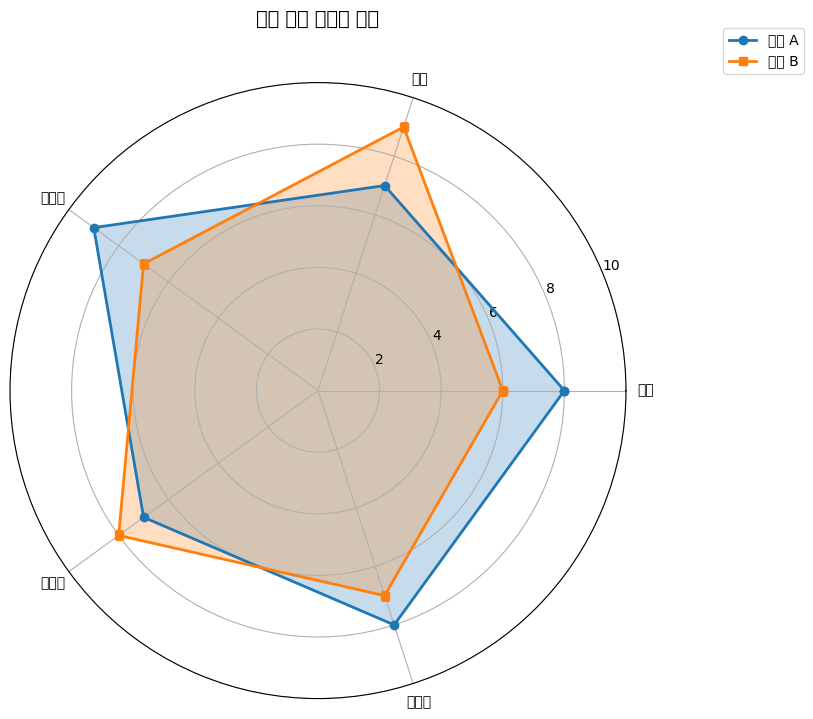

In [29]:
# 레이더 차트
categories = ['성능', '가격', '디자인', '내구성', '효율성']
product_a = [8, 7, 9, 7, 8]
product_b = [6, 9, 7, 8, 7]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
product_a += product_a[:1]
product_b += product_b[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

ax.plot(angles, product_a, 'o-', linewidth=2, label='제품 A')
ax.fill(angles, product_a, alpha=0.25)

ax.plot(angles, product_b, 's-', linewidth=2, label='제품 B')
ax.fill(angles, product_b, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 10)
ax.set_title('제품 비교 레이더 차트', size=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.show()

# 10. 서브플롯 고급 레이아웃

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45331 (\N{HANGUL SYLLABLE NEOLB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) m

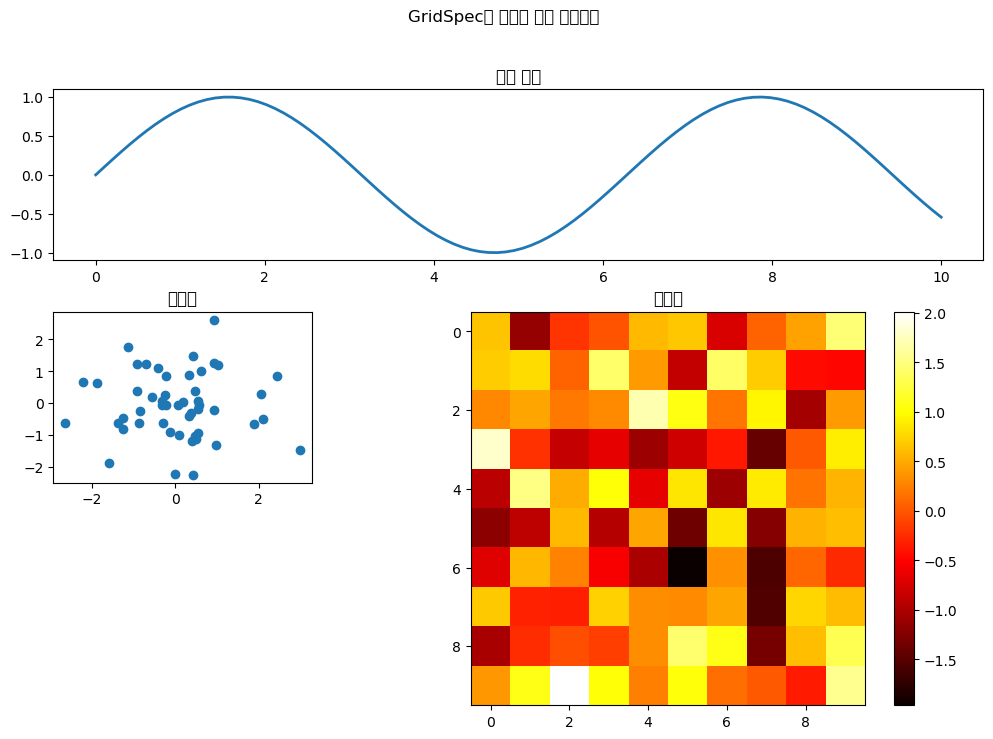

In [30]:
# GridSpec 사용 - 불규칙한 레이아웃
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1행 3열을 차지하는 플롯
ax1 = fig.add_subplot(gs[0, :])
x = np.linspace(0, 10, 100)
ax1.plot(x, np.sin(x), linewidth=2)
ax1.set_title('넓은 플롯')

# 2행 1열
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(np.random.randn(50), np.random.randn(50))
ax2.set_title('산점도')

# 2행 2~3열
ax3 = fig.add_subplot(gs[1:, 1:])
data = np.random.randn(10, 10)
im = ax3.imshow(data, cmap='hot')
ax3.set_title('이미지')
plt.colorbar(im, ax=ax3)

plt.suptitle('GridSpec을 이용한 고급 레이아웃')
plt.show()

# 11. 통계 플롯

C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\4015043025.py:21: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from current font.
  plt.tight_layout()
C:\Us

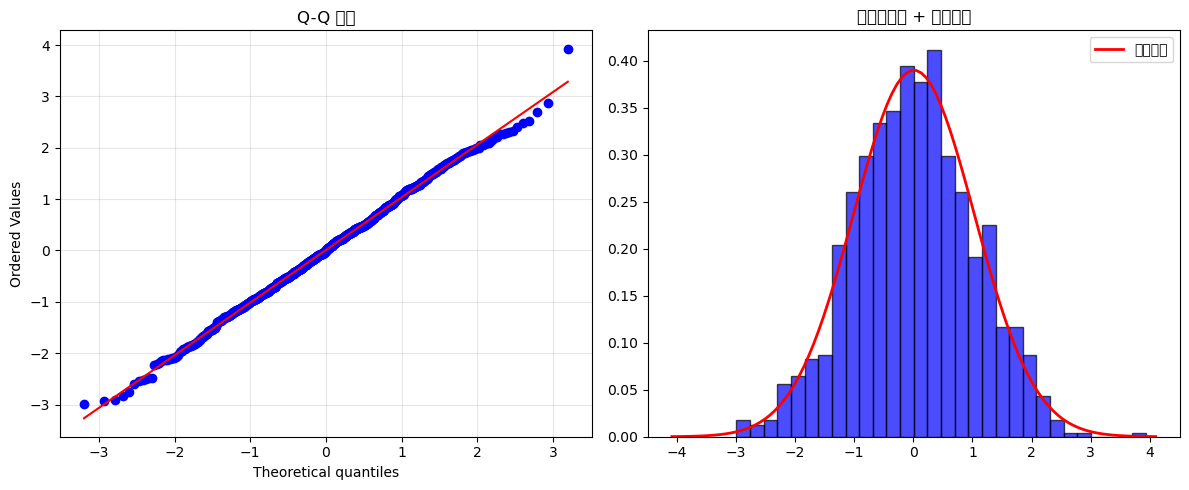

In [31]:
from scipy import stats

# Q-Q 플롯 (정규성 검정)
data = np.random.normal(0, 1, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q 플롯
stats.probplot(data, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q 플롯')
axes[0].grid(alpha=0.3)

# 히스토그램 + 정규분포 곡선
axes[1].hist(data, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
mu, sigma = np.mean(data), np.std(data)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='정규분포')
axes[1].set_title('히스토그램 + 정규분포')
axes[1].legend()

plt.tight_layout()
plt.show()

# 12. 지도 시각화 (기본)

C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20092\3642658024.py:23: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  plt.tight_layout()
C:\U

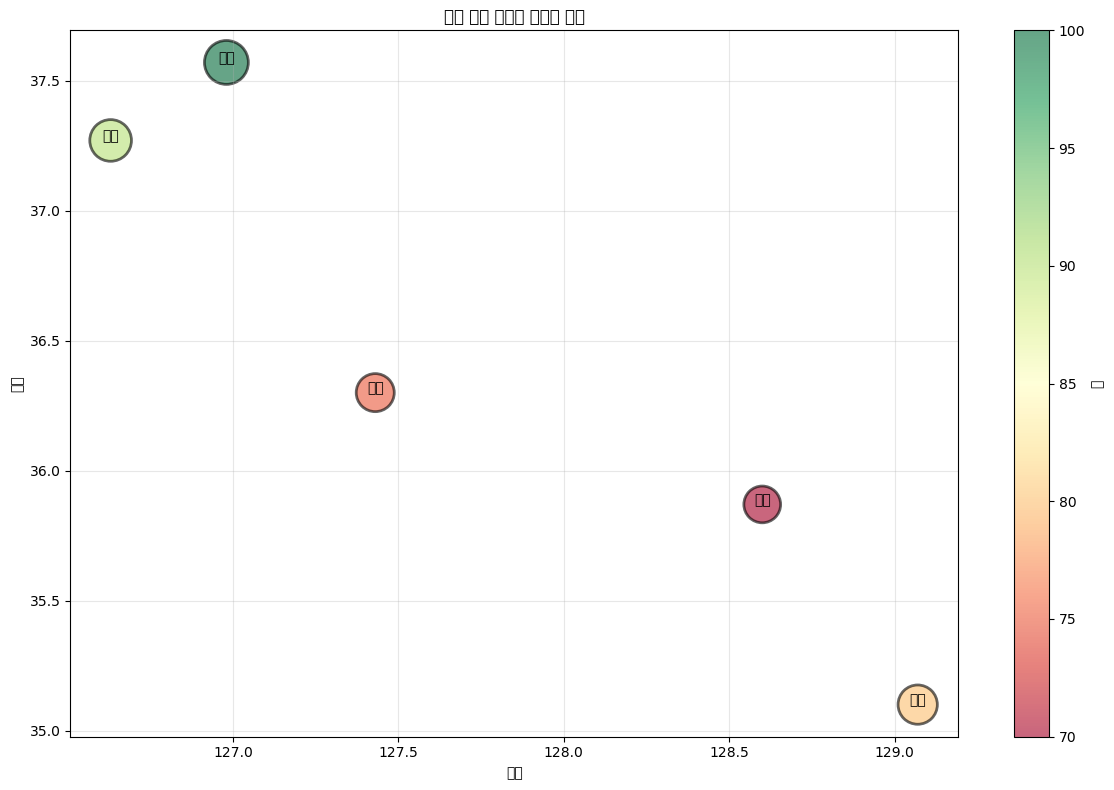

In [32]:
# 지역별 데이터 분포 시뮬레이션
np.random.seed(42)
cities = ['서울', '부산', '인천', '대구', '대전']
lat = [37.57, 35.10, 37.27, 35.87, 36.30]
lon = [126.98, 129.07, 126.63, 128.60, 127.43]
values = [100, 80, 90, 70, 75]

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(lon, lat, s=[v*10 for v in values], 
                     c=values, cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=2)

for i, city in enumerate(cities):
    ax.annotate(city, (lon[i], lat[i]), ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.set_title('한국 주요 도시별 데이터 분포')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('값')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()